# Pre-entrega: Pipeline de entrenamiento y validación en PyTorch

## Clasificador base sobre el dataset Iris

### Objetivo

Construir un pipeline reproducible de clasificación utilizando PyTorch, que incluya:

- configuración automática del dispositivo;
- fijación de semillas de aleatoriedad;
- preparación de los datos;
- definición de una red neuronal base;
- ciclo explícito de entrenamiento;
- ciclo de validación;
- registro de pérdida y accuracy por época;
- visualización de métricas;
- evaluación final del modelo.

El objetivo principal: implementar correctamente el ciclo de vida inicial de un modelo de aprendizaje profundo.

## 1. Importación de librerías

In [20]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import random
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset

**Recordatorio de Usos**

random: controla valores aleatorios propios de Python.

numpy: operaciones numéricas y semillas.

pandas: exploración y organización de los datos.

matplotlib: gráficos de pérdida y accuracy.

sklearn: dataset Iris, separación y normalización.

torch: tensores y operaciones de PyTorch.

torch.nn: capas y funciones para construir el modelo.

torch.optim: optimizadores, como Adam.

DataLoader: entrega los datos al modelo en pequeños lotes o batches.

## 2. Comprobar versiones

In [21]:
# ============================================================
# 2. INFORMACIÓN DEL ENTORNO
# ============================================================

print("Información del entorno")
print("-" * 40)

print(f"Python:        {platform.python_version()}")
print(f"PyTorch:       {torch.__version__}")
print(f"NumPy:         {np.__version__}")
print(f"Pandas:        {pd.__version__}")
print(f"Scikit-learn:  {sklearn.__version__}")

Información del entorno
----------------------------------------
Python:        3.12.13
PyTorch:       2.11.0+cpu
NumPy:         2.0.2
Pandas:        2.2.2
Scikit-learn:  1.6.1


## 3. Fijar las semillas

In [22]:
# ============================================================
# 3. CONFIGURACIÓN DE REPRODUCIBILIDAD
# ============================================================

SEED = 42


def configurar_semillas(seed: int = 42) -> None:
    """
    Fija las semillas de aleatoriedad utilizadas por
    Python, NumPy y PyTorch.

    Esto ayuda a obtener resultados reproducibles
    entre diferentes ejecuciones del experimento.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Configuración para GPU NVIDIA
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        # Configuración adicional de reproducibilidad
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # Configuración para dispositivos Apple con MPS
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


configurar_semillas(SEED)

print(f"Semilla configurada: {SEED}")

Semilla configurada: 42


## 4. Detectar el dispositivo

In [23]:
# ============================================================
# 4. DETECCIÓN AUTOMÁTICA DEL DISPOSITIVO
# ============================================================


def obtener_dispositivo() -> torch.device:
    """
    Selecciona automáticamente el mejor dispositivo disponible.

    Prioridad:
    1. CUDA: GPU NVIDIA
    2. MPS: GPU Apple
    3. CPU
    """

    if torch.cuda.is_available():
        return torch.device("cuda")

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")

    return torch.device("cpu")


device = obtener_dispositivo()

print(f"Dispositivo seleccionado: {device}")

if device.type == "cuda":
    print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
elif device.type == "mps":
    print("GPU Apple disponible mediante MPS")
else:
    print("El entrenamiento se realizará en CPU")

Dispositivo seleccionado: cpu
El entrenamiento se realizará en CPU


## 5. Verificar que los tensores se muevan correctamente

In [24]:
# ============================================================
# 5. PRUEBA DEL DISPOSITIVO
# ============================================================

tensor_prueba = torch.tensor(
    [1.0, 2.0, 3.0],
    dtype=torch.float32
)

tensor_prueba = tensor_prueba.to(device)

print("Tensor de prueba:", tensor_prueba)
print("Dispositivo del tensor:", tensor_prueba.device)

Tensor de prueba: tensor([1., 2., 3.])
Dispositivo del tensor: cpu


## 6. Carga y exploración del dataset Iris

En esta sección se carga el dataset Iris desde Scikit-learn y se realiza una exploración inicial de las variables, clases, dimensiones y calidad de los datos.

6.1 Cargar el dataset

In [25]:
# ============================================================
# 6. CARGA DEL DATASET IRIS
# ============================================================

from sklearn.datasets import load_iris

# Se carga el dataset como un DataFrame de pandas
iris = load_iris(as_frame=True)

# Copiamos el DataFrame para trabajar sin modificar
# directamente el objeto original
df_iris = iris.frame.copy()

print("Dataset Iris cargado correctamente.")

Dataset Iris cargado correctamente.


6.2 Conocer la estructura del objeto Iris

In [26]:
# Información general disponible en el dataset

print("Variables predictoras:")
print(iris.feature_names)

print("\nClases del problema:")
print(iris.target_names)

print("\nNombre de la variable objetivo:")
print(iris.target_names)

Variables predictoras:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Clases del problema:
['setosa' 'versicolor' 'virginica']

Nombre de la variable objetivo:
['setosa' 'versicolor' 'virginica']


6.3 Agregar el nombre de la especie

In [27]:
# Diccionario que relaciona cada número con su especie

mapa_especies = {
    indice: especie
    for indice, especie in enumerate(iris.target_names)
}

# Se agrega una columna descriptiva
df_iris["especie"] = df_iris["target"].map(mapa_especies)

print("Mapa de clases:")
print(mapa_especies)

Mapa de clases:
{0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


6.4 Visualizar algunos registros

In [28]:
# Se muestran cinco registros aleatorios

df_iris.sample(
    n=5,
    random_state=SEED
)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,especie
73,6.1,2.8,4.7,1.2,1,versicolor
18,5.7,3.8,1.7,0.3,0,setosa
118,7.7,2.6,6.9,2.3,2,virginica
78,6.0,2.9,4.5,1.5,1,versicolor
76,6.8,2.8,4.8,1.4,1,versicolor


## 7. Revisar dimensiones

In [29]:
# ============================================================
# 7. DIMENSIONES DEL DATASET
# ============================================================

cantidad_filas = df_iris.shape[0]
cantidad_columnas = df_iris.shape[1]

print(f"Cantidad de registros: {cantidad_filas}")
print(f"Cantidad de columnas:  {cantidad_columnas}")

Cantidad de registros: 150
Cantidad de columnas:  6


In [30]:
# Tipos de datos y valores no nulos

df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   especie            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


## 8. Valores faltantes

In [31]:
# ============================================================
# 8. CONTROL DE VALORES FALTANTES
# ============================================================

valores_faltantes = df_iris.isnull().sum()

print("Valores faltantes por columna:")
print(valores_faltantes)

print("\nTotal de valores faltantes:")
print(valores_faltantes.sum())

Valores faltantes por columna:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
especie              0
dtype: int64

Total de valores faltantes:
0


## 9. Distribucipon de clases

In [32]:
# ============================================================
# 9. DISTRIBUCIÓN DE LAS CLASES
# ============================================================

distribucion_clases = (
    df_iris["especie"]
    .value_counts()
    .sort_index()
)

print("Cantidad de registros por especie:")
print(distribucion_clases)

Cantidad de registros por especie:
especie
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 10. Estadísticas descriptivas

In [33]:
# ============================================================
# 10. ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# Preparación y división de los datos

El dataset se dividirá en tres subconjuntos:

- **Entrenamiento:** utilizado para ajustar los parámetros del modelo.
- **Validación:** utilizado durante el experimento para evaluar el desempeño sobre datos no vistos y detectar posibles señales de overfitting.
- **Prueba:** reservado para realizar la evaluación final del modelo.

La división se realiza de manera estratificada para conservar la proporción de las tres especies en cada subconjunto:

*   aproximadamente 70 % para entrenamiento;
*   aproximadamente 15 % para validación;
*   aproximadamente 15 % para prueba.


## 11. Separación de variables predictoras y objetivo

In [34]:
# ============================================================
# 11. SEPARACIÓN DE VARIABLES PREDICTORAS Y OBJETIVO
# ============================================================

# X contiene las cuatro medidas de cada flor
X = df_iris[iris.feature_names].copy()

# y contiene la clase numérica de cada flor
y = df_iris["target"].copy()

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

print("\nVariables predictoras:")
print(list(X.columns))

print("\nValores posibles de la variable objetivo:")
print(sorted(y.unique()))

Dimensión de X: (150, 4)
Dimensión de y: (150,)

Variables predictoras:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Valores posibles de la variable objetivo:
[np.int64(0), np.int64(1), np.int64(2)]


## 12. Primera división

In [35]:
# ============================================================
# 12. DIVISIÓN EN ENTRENAMIENTO Y CONJUNTO TEMPORAL
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

print("Registros de entrenamiento:", len(X_train))
print("Registros temporales:", len(X_temp))

Registros de entrenamiento: 105
Registros temporales: 45


## 13. Validación y prueba

In [36]:
# ============================================================
# 13. DIVISIÓN DEL CONJUNTO TEMPORAL
# ============================================================

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Cantidad de registros por conjunto")
print("-" * 40)
print(f"Entrenamiento: {len(X_train)}")
print(f"Validación:    {len(X_val)}")
print(f"Prueba:        {len(X_test)}")

print("\nTotal:", len(X_train) + len(X_val) + len(X_test))

Cantidad de registros por conjunto
----------------------------------------
Entrenamiento: 105
Validación:    22
Prueba:        23

Total: 150


## 14. Comprobar la distribución de las clases

In [37]:
# ============================================================
# 14. CONTROL DE DISTRIBUCIÓN DE CLASES
# ============================================================


def mostrar_distribucion(nombre, etiquetas):
    """
    Muestra la cantidad de observaciones de cada clase
    dentro de un subconjunto.
    """

    distribucion = (
        etiquetas
        .value_counts()
        .sort_index()
        .rename(index=mapa_especies)
    )

    print(f"\n{nombre}")
    print(distribucion)


mostrar_distribucion("Entrenamiento", y_train)
mostrar_distribucion("Validación", y_val)
mostrar_distribucion("Prueba", y_test)


Entrenamiento
target
setosa        35
versicolor    35
virginica     35
Name: count, dtype: int64

Validación
target
setosa        8
versicolor    7
virginica     7
Name: count, dtype: int64

Prueba
target
setosa        7
versicolor    8
virginica     8
Name: count, dtype: int64


# Estandarización de las variables

Las variables predictoras se estandarizan utilizando StandardScaler.

El escalador se ajusta exclusivamente con el conjunto de entrenamiento. Luego, esa misma transformación se aplica a validación y prueba.

Esto evita el data leakage, ya que el modelo no debe utilizar información estadística de los conjuntos que simulan datos no vistos.

## 15. Ajustar el escalador

In [38]:
# ============================================================
# 15. ESTANDARIZACIÓN DE VARIABLES
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# El escalador aprende solamente de los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Validación y prueba utilizan la transformación aprendida
# con el conjunto de entrenamiento
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Estandarización completada correctamente.")

Estandarización completada correctamente.


## 16. Verificar el resultado de estandarización

In [39]:
# ============================================================
# 16. VERIFICACIÓN DE LA ESTANDARIZACIÓN
# ============================================================

print("Promedio de las variables de entrenamiento:")
print(np.round(X_train_scaled.mean(axis=0), 4))

print("\nDesviación estándar de las variables de entrenamiento:")
print(np.round(X_train_scaled.std(axis=0), 4))

print("\nDimensiones después de la transformación:")
print("Train:", X_train_scaled.shape)
print("Validación:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Promedio de las variables de entrenamiento:
[ 0. -0. -0. -0.]

Desviación estándar de las variables de entrenamiento:
[1. 1. 1. 1.]

Dimensiones después de la transformación:
Train: (105, 4)
Validación: (22, 4)
Test: (23, 4)


# Conversión a tensores y creación de DataLoaders

Los datos estandarizados se convierten en tensores de PyTorch.

Las variables predictoras utilizan el tipo float32, mientras que las etiquetas utilizan long, requerido por la función de pérdida CrossEntropyLoss.

Usamos float32 para las caracteristicas porque la red neuronal realizara operaciones matematicas con numeros decimales, y para las etuquetas se usa long porque CrossEntropyLoss espera que cada clase esté representada por un numero entero.

Con esto, los tensores se organizan mediante TensorDataset y DataLoader para entregar los datos al modelo en pequeños lotes o batches.

## 17. Convertir las variables predictoras

In [40]:
# ============================================================
# 17. CONVERSIÓN DE VARIABLES PREDICTORAS A TENSORES
# ============================================================

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

print("Tensores de variables predictoras creados.")
print()
print("Train:", X_train_tensor.shape, X_train_tensor.dtype)
print("Validación:", X_val_tensor.shape, X_val_tensor.dtype)
print("Test:", X_test_tensor.shape, X_test_tensor.dtype)

Tensores de variables predictoras creados.

Train: torch.Size([105, 4]) torch.float32
Validación: torch.Size([22, 4]) torch.float32
Test: torch.Size([23, 4]) torch.float32


## 18. Convertir las etiquetas

In [41]:
# ============================================================
# 18. CONVERSIÓN DE ETIQUETAS A TENSORES
# ============================================================

y_train_tensor = torch.tensor(
    y_train.to_numpy(),
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val.to_numpy(),
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test.to_numpy(),
    dtype=torch.long
)

print("Tensores de etiquetas creados.")
print()
print("Train:", y_train_tensor.shape, y_train_tensor.dtype)
print("Validación:", y_val_tensor.shape, y_val_tensor.dtype)
print("Test:", y_test_tensor.shape, y_test_tensor.dtype)

Tensores de etiquetas creados.

Train: torch.Size([105]) torch.int64
Validación: torch.Size([22]) torch.int64
Test: torch.Size([23]) torch.int64


## 19. Creación de TensorDataset

In [42]:
# ============================================================
# 19. CREACIÓN DE LOS DATASETS DE PYTORCH
# ============================================================

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

print("Cantidad de registros por TensorDataset")
print("-" * 40)
print(f"Entrenamiento: {len(train_dataset)}")
print(f"Validación:    {len(val_dataset)}")
print(f"Prueba:        {len(test_dataset)}")

Cantidad de registros por TensorDataset
----------------------------------------
Entrenamiento: 105
Validación:    22
Prueba:        23


## 20. Creación de DataLoaders

In [43]:
# ============================================================
# 20. CONFIGURACIÓN DE LOS DATALOADERS
# ============================================================

BATCH_SIZE = 16

# Generador con semilla para que el mezclado del conjunto
# de entrenamiento sea reproducible
generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Batch size configurado: {BATCH_SIZE}")
print()
print("Cantidad de batches")
print("-" * 40)
print(f"Entrenamiento: {len(train_loader)}")
print(f"Validación:    {len(val_loader)}")
print(f"Prueba:        {len(test_loader)}")

Batch size configurado: 16

Cantidad de batches
----------------------------------------
Entrenamiento: 7
Validación:    2
Prueba:        2


## 21. Inspeccionar un batch

Comprobar que devuelve el DataLoader

In [44]:
# ============================================================
# 21. INSPECCIÓN DE UN BATCH
# ============================================================

features_batch, labels_batch = next(iter(train_loader))

print("Dimensión del batch de variables:", features_batch.shape)
print("Dimensión del batch de etiquetas:", labels_batch.shape)

print("\nTipo de las variables:")
print(features_batch.dtype)

print("\nTipo de las etiquetas:")
print(labels_batch.dtype)

print("\nPrimer registro del batch:")
print(features_batch[0])

print("\nEtiqueta numérica:")
print(labels_batch[0].item())

print("\nEspecie:")
print(iris.target_names[labels_batch[0].item()])

Dimensión del batch de variables: torch.Size([16, 4])
Dimensión del batch de etiquetas: torch.Size([16])

Tipo de las variables:
torch.float32

Tipo de las etiquetas:
torch.int64

Primer registro del batch:
tensor([-1.2498,  0.7577, -1.0615, -1.2996])

Etiqueta numérica:
0

Especie:
setosa


## 22. Comprobar el dispositivo actual de los batches

In [45]:
# ============================================================
# 22. COMPROBACIÓN DEL DISPOSITIVO
# ============================================================

print("Dispositivo actual de las variables:")
print(features_batch.device)

print("\nDispositivo actual de las etiquetas:")
print(labels_batch.device)

Dispositivo actual de las variables:
cpu

Dispositivo actual de las etiquetas:
cpu


# Arquitectura del clasificador base

Se implementa una red neuronal multicapa o MLP mediante una clase que hereda de nn.Module.

La arquitectura recibe cuatro variables de entrada, correspondientes a las medidas de cada flor, y genera tres valores de salida, uno por cada especie posible.

La red utiliza capas lineales y la función de activación ReLU.

## 23. Definición de la arquitectura

In [46]:
# ============================================================
# 23. DEFINICIÓN DE LA ARQUITECTURA
# ============================================================


class ClasificadorIris(nn.Module):
    """
    Red neuronal multicapa para clasificar las tres
    especies presentes en el dataset Iris.
    """

    def __init__(
        self,
        input_size: int = 4,
        hidden_size_1: int = 16,
        hidden_size_2: int = 8,
        num_classes: int = 3
    ) -> None:
        super().__init__()

        self.red = nn.Sequential(
            nn.Linear(input_size, hidden_size_1),
            nn.ReLU(),

            nn.Linear(hidden_size_1, hidden_size_2),
            nn.ReLU(),

            nn.Linear(hidden_size_2, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Ejecuta el forward pass del modelo.
        """

        return self.red(x)

## 24. Instanciar el modelo

In [47]:
# ============================================================
# 24. CREACIÓN DEL MODELO
# ============================================================

model = ClasificadorIris()

# El modelo se mueve al dispositivo seleccionado
model = model.to(device)

print("Arquitectura del modelo")
print("-" * 50)
print(model)

print("\nDispositivo del modelo:")
print(next(model.parameters()).device)

Arquitectura del modelo
--------------------------------------------------
ClasificadorIris(
  (red): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)

Dispositivo del modelo:
cpu


## 25. Contar los parámetros

In [48]:
# ============================================================
# 25. CANTIDAD DE PARÁMETROS
# ============================================================

parametros_totales = sum(
    parametro.numel()
    for parametro in model.parameters()
)

parametros_entrenables = sum(
    parametro.numel()
    for parametro in model.parameters()
    if parametro.requires_grad
)

print(f"Parámetros totales:     {parametros_totales}")
print(f"Parámetros entrenables: {parametros_entrenables}")

Parámetros totales:     243
Parámetros entrenables: 243


## 26. Probar el forward pass
Antes de entrenar, se comprueba que el modelo puede recibir un batch y producir una salida válida.

In [49]:
# ============================================================
# 26. PRUEBA DEL FORWARD PASS
# ============================================================

# Movemos el batch al mismo dispositivo que el modelo
features_batch = features_batch.to(device)
labels_batch = labels_batch.to(device)

# Ejecutamos el modelo sin calcular gradientes
with torch.no_grad():
    outputs_batch = model(features_batch)

print("Dimensión del batch de entrada:")
print(features_batch.shape)

print("\nDimensión de la salida del modelo:")
print(outputs_batch.shape)

print("\nSalida correspondiente al primer registro:")
print(outputs_batch[0])

Dimensión del batch de entrada:
torch.Size([16, 4])

Dimensión de la salida del modelo:
torch.Size([16, 3])

Salida correspondiente al primer registro:
tensor([ 0.1367, -0.1907, -0.1111])


## 27. Prediccion inicial

In [50]:
# ============================================================
# 27. PREDICCIÓN INICIAL DEL MODELO
# ============================================================

predicciones_batch = outputs_batch.argmax(dim=1)

primera_prediccion = predicciones_batch[0].item()
primera_etiqueta_real = labels_batch[0].item()

print("Predicción numérica:")
print(primera_prediccion)

print("\nEspecie predicha:")
print(iris.target_names[primera_prediccion])

print("\nEtiqueta real:")
print(primera_etiqueta_real)

print("\nEspecie real:")
print(iris.target_names[primera_etiqueta_real])

Predicción numérica:
0

Especie predicha:
setosa

Etiqueta real:
0

Especie real:
setosa


## 28. Accuracy

In [51]:
# ============================================================
# 28. ACCURACY INICIAL DEL BATCH
# ============================================================

predicciones_correctas = (
    predicciones_batch == labels_batch
).sum().item()

cantidad_registros = labels_batch.size(0)

accuracy_inicial = (
    predicciones_correctas / cantidad_registros
)

print(f"Predicciones correctas: {predicciones_correctas}")
print(f"Cantidad de registros:  {cantidad_registros}")
print(f"Accuracy inicial:        {accuracy_inicial:.4f}")
print(f"Accuracy inicial:        {accuracy_inicial * 100:.2f}%")

Predicciones correctas: 7
Cantidad de registros:  16
Accuracy inicial:        0.4375
Accuracy inicial:        43.75%


## 29. Función de pérdida y optimizador

Para medir el error del modelo se utiliza CrossEntropyLoss, apropiada para problemas de clasificación multiclase.

Para actualizar los pesos se utiliza el optimizador Adam, con un learning rate inicial de 0.001.

In [52]:
# ============================================================
# 29. FUNCIÓN DE PÉRDIDA Y OPTIMIZADOR
# ============================================================

LEARNING_RATE = 0.001
EPOCHS = 50

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Configuración del entrenamiento")
print("-" * 40)
print(f"Función de pérdida: {criterion}")
print(f"Optimizador:        {optimizer.__class__.__name__}")
print(f"Learning rate:      {LEARNING_RATE}")
print(f"Cantidad de épocas: {EPOCHS}")

Configuración del entrenamiento
----------------------------------------
Función de pérdida: CrossEntropyLoss()
Optimizador:        Adam
Learning rate:      0.001
Cantidad de épocas: 50


#  Ciclos de entrenamiento y validación

El ciclo de entrenamiento aplica las siguientes etapas:

1. Forward pass.
2. Cálculo de la pérdida.
3. Reinicio de gradientes.
4. Backward pass.
5. Actualización de los pesos.

Después de cada epoca, el modelo se evalúa sobre el conjunto de validación sin actualizar sus parámetros.

Se registran la pérdida y el accuracy de entrenamiento y validación para analizar posteriormente la evolución del modelo.

## 30.Función para entrenar una época

In [53]:
# ============================================================
# 30. FUNCIÓN DE ENTRENAMIENTO
# ============================================================


def entrenar_una_epoca(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device
) -> tuple[float, float]:
    """
    Entrena el modelo durante una época completa.

    Retorna:
        - pérdida promedio de entrenamiento;
        - accuracy de entrenamiento.
    """

    # Activa el modo de entrenamiento
    model.train()

    perdida_acumulada = 0.0
    predicciones_correctas = 0
    cantidad_registros = 0

    for features, labels in data_loader:

        # Los datos y el modelo deben estar
        # ubicados en el mismo dispositivo
        features = features.to(device)
        labels = labels.to(device)

        # 1. Reiniciar los gradientes acumulados
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(features)

        # 3. Calcular la pérdida
        loss = criterion(outputs, labels)

        # 4. Backward pass
        loss.backward()

        # 5. Actualizar los pesos
        optimizer.step()

        # Cantidad de registros del batch actual
        batch_size = labels.size(0)

        # Acumular la pérdida ponderada por el tamaño del batch
        perdida_acumulada += loss.item() * batch_size

        # Obtener la clase con el logit más alto
        predictions = outputs.argmax(dim=1)

        # Contar predicciones correctas
        predicciones_correctas += (
            predictions == labels
        ).sum().item()

        cantidad_registros += batch_size

    perdida_promedio = (
        perdida_acumulada / cantidad_registros
    )

    accuracy = (
        predicciones_correctas / cantidad_registros
    )

    return perdida_promedio, accuracy

## 31. Función de validación

In [54]:
# ============================================================
# 31. FUNCIÓN DE VALIDACIÓN
# ============================================================


def evaluar_modelo(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device
) -> tuple[float, float]:
    """
    Evalúa el modelo sin actualizar sus parámetros.

    Retorna:
        - pérdida promedio;
        - accuracy.
    """

    # Activa el modo de evaluación
    model.eval()

    perdida_acumulada = 0.0
    predicciones_correctas = 0
    cantidad_registros = 0

    # Durante la evaluación no se calculan gradientes
    with torch.no_grad():

        for features, labels in data_loader:

            features = features.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(features)

            # Cálculo de pérdida
            loss = criterion(outputs, labels)

            batch_size = labels.size(0)

            perdida_acumulada += (
                loss.item() * batch_size
            )

            predictions = outputs.argmax(dim=1)

            predicciones_correctas += (
                predictions == labels
            ).sum().item()

            cantidad_registros += batch_size

    perdida_promedio = (
        perdida_acumulada / cantidad_registros
    )

    accuracy = (
        predicciones_correctas / cantidad_registros
    )

    return perdida_promedio, accuracy

## 32. Ejecución del entrenamiento

El modelo se entrena durante 50 épocas.

Después de cada época se calculan:

- pérdida de entrenamiento;
- accuracy de entrenamiento;
- pérdida de validación;
- accuracy de validación.

Los resultados se almacenan para construir posteriormente las curvas de aprendizaje.

In [55]:
# ============================================================
# 32. LOOP COMPLETO DE ENTRENAMIENTO
# ============================================================

historial = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

print("Inicio del entrenamiento")
print("=" * 80)

for epoch in range(1, EPOCHS + 1):

    # Entrenamiento
    train_loss, train_accuracy = entrenar_una_epoca(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    # Validación
    val_loss, val_accuracy = evaluar_modelo(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=device
    )

    # Guardar métricas de la época
    historial["train_loss"].append(train_loss)
    historial["train_accuracy"].append(train_accuracy)
    historial["val_loss"].append(val_loss)
    historial["val_accuracy"].append(val_accuracy)

    # Mostrar resultados
    print(
        f"Época {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:6.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy * 100:6.2f}%"
    )

print("=" * 80)
print("Entrenamiento finalizado.")

Inicio del entrenamiento
Época 01/50 | Train Loss: 1.0883 | Train Acc:  34.29% | Val Loss: 1.0774 | Val Acc:  36.36%
Época 02/50 | Train Loss: 1.0730 | Train Acc:  40.00% | Val Loss: 1.0655 | Val Acc:  36.36%
Época 03/50 | Train Loss: 1.0582 | Train Acc:  50.48% | Val Loss: 1.0524 | Val Acc:  50.00%
Época 04/50 | Train Loss: 1.0426 | Train Acc:  55.24% | Val Loss: 1.0373 | Val Acc:  50.00%
Época 05/50 | Train Loss: 1.0252 | Train Acc:  58.10% | Val Loss: 1.0206 | Val Acc:  63.64%
Época 06/50 | Train Loss: 1.0049 | Train Acc:  61.90% | Val Loss: 1.0019 | Val Acc:  63.64%
Época 07/50 | Train Loss: 0.9836 | Train Acc:  64.76% | Val Loss: 0.9815 | Val Acc:  63.64%
Época 08/50 | Train Loss: 0.9607 | Train Acc:  66.67% | Val Loss: 0.9589 | Val Acc:  63.64%
Época 09/50 | Train Loss: 0.9357 | Train Acc:  66.67% | Val Loss: 0.9346 | Val Acc:  63.64%
Época 10/50 | Train Loss: 0.9090 | Train Acc:  68.57% | Val Loss: 0.9082 | Val Acc:  72.73%
Época 11/50 | Train Loss: 0.8802 | Train Acc:  73.33% |

## 33. Convertir el historial en una tabla

In [56]:
# ============================================================
# 33. TABLA DE MÉTRICAS POR ÉPOCA
# ============================================================

df_historial = pd.DataFrame({
    "epoch": range(1, EPOCHS + 1),
    "train_loss": historial["train_loss"],
    "val_loss": historial["val_loss"],
    "train_accuracy": historial["train_accuracy"],
    "val_accuracy": historial["val_accuracy"]
})

df_historial.head()

,epoch,train_loss,val_loss,train_accuracy,val_accuracy
0,1,1.088343,1.077369,0.342857,0.363636
1,2,1.073015,1.065457,0.400000,0.363636
2,3,1.058237,1.052419,0.504762,0.500000
3,4,1.042580,1.037307,0.552381,0.500000
4,5,1.025199,1.020579,0.580952,0.636364


In [57]:
df_historial.iloc[23:28]

,epoch,train_loss,val_loss,train_accuracy,val_accuracy
23,24,0.483644,0.499720,0.838095,0.863636
24,25,0.463424,0.481000,0.857143,0.863636
25,26,0.444410,0.464154,0.876190,0.863636
26,27,0.427487,0.449102,0.876190,0.863636
27,28,0.411681,0.435090,0.866667,0.863636


In [58]:
df_historial.tail()

,epoch,train_loss,val_loss,train_accuracy,val_accuracy
45,46,0.244002,0.306260,0.92381,0.863636
46,47,0.237911,0.301068,0.92381,0.863636
47,48,0.232409,0.297411,0.92381,0.909091
48,49,0.226961,0.293191,0.92381,0.909091
49,50,0.221832,0.290030,0.92381,0.909091


## Interpretación de los resultados

*   la pérdida de entrenamiento disminuyó de forma constante;
*   la pérdida de validación también siguió bajando;
*   el accuracy aumentó considerablemente;
*   entrenamiento y validación terminaron con resultados cercanos;
*   no hay evidencia clara de overfitting importante.



## 34. Curvas de aprendizaje

Se representan gráficamente la pérdida y el accuracy obtenidos durante las épocas de entrenamiento.

Estas curvas permiten analizar si el modelo aprendió correctamente y detectar posibles diferencias entre el desempeño de entrenamiento y validación.

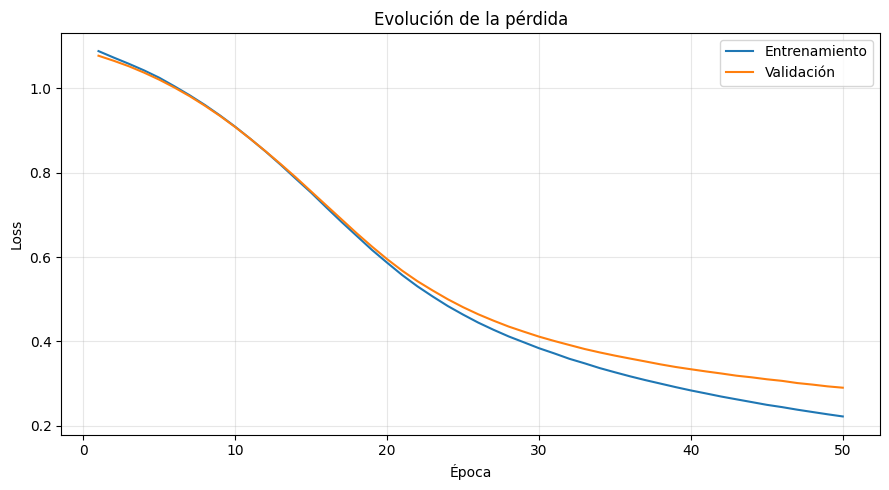

In [59]:
# ============================================================
# 34. CURVA DE PÉRDIDA
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    df_historial["epoch"],
    df_historial["train_loss"],
    label="Entrenamiento"
)

plt.plot(
    df_historial["epoch"],
    df_historial["val_loss"],
    label="Validación"
)

plt.title("Evolución de la pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

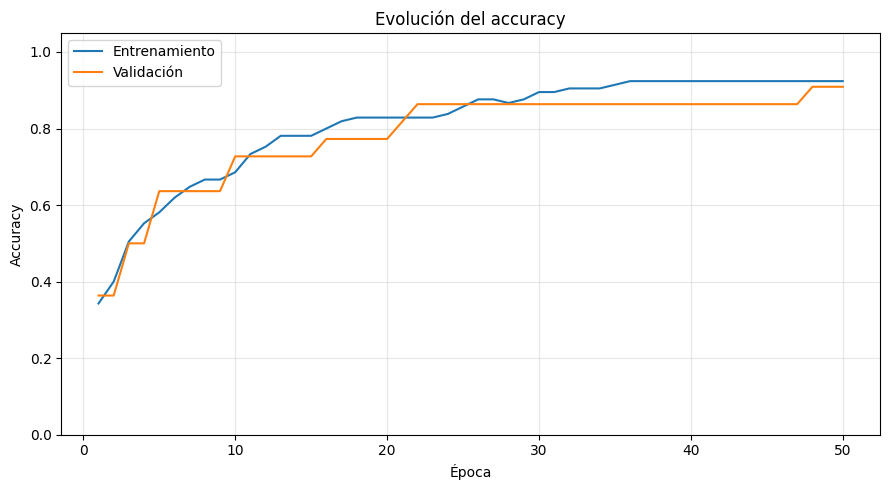

In [60]:
# ============================================================
# 35. CURVA DE ACCURACY
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    df_historial["epoch"],
    df_historial["train_accuracy"],
    label="Entrenamiento"
)

plt.plot(
    df_historial["epoch"],
    df_historial["val_accuracy"],
    label="Validación"
)

plt.title("Evolución del accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 36. Resumen de métricas finales

In [61]:
# ============================================================
# 36. RESUMEN DEL ENTRENAMIENTO
# ============================================================

ultima_epoca = df_historial.iloc[-1]

print("Resultados de la última época")
print("-" * 45)

print(
    f"Train Loss:      "
    f"{ultima_epoca['train_loss']:.4f}"
)

print(
    f"Validation Loss: "
    f"{ultima_epoca['val_loss']:.4f}"
)

print(
    f"Train Accuracy:  "
    f"{ultima_epoca['train_accuracy'] * 100:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{ultima_epoca['val_accuracy'] * 100:.2f}%"
)

Resultados de la última época
---------------------------------------------
Train Loss:      0.2218
Validation Loss: 0.2900
Train Accuracy:  92.38%
Validation Accuracy: 90.91%


In [62]:
# ============================================================
# 37. MEJOR ÉPOCA SEGÚN VALIDATION LOSS
# ============================================================

indice_mejor_epoca = df_historial["val_loss"].idxmin()
mejor_epoca = df_historial.loc[indice_mejor_epoca]

print("Mejor época según la pérdida de validación")
print("-" * 50)

print(f"Época:               {int(mejor_epoca['epoch'])}")
print(f"Validation Loss:     {mejor_epoca['val_loss']:.4f}")
print(
    f"Validation Accuracy: "
    f"{mejor_epoca['val_accuracy'] * 100:.2f}%"
)

Mejor época según la pérdida de validación
--------------------------------------------------
Época:               50
Validation Loss:     0.2900
Validation Accuracy: 90.91%


# Interpretación de los resultados de entrenamiento y validación

Al observar los gráficos, se puede ver que el modelo fue aprendiendo durante las 50 épocas.

La pérdida de entrenamiento y la pérdida de validación fueron disminuyendo de manera progresiva. Esto significa que el modelo fue reduciendo sus errores tanto con los datos utilizados para entrenar como con los datos de validación.

Por otro lado, el accuracy fue aumentando a medida que avanzaron las épocas. Al finalizar, el modelo obtuvo un accuracy de 92,38 % en entrenamiento y de 90,91 % en validación.

Los resultados de entrenamiento y validación son bastante cercanos. Además, la pérdida de validación continuó disminuyendo hasta la última época, por lo que en este experimento no se observan señales importantes de overfitting.

La mejor época según la pérdida de validación fue la época 50, con una pérdida de 0,2900 y un accuracy de 90,91 %.

## 38. Evaluación sobre el conjunto de prueba

Finalizado el entrenamiento y seleccionada la mejor época mediante el conjunto de validación, se evalúa el modelo sobre el conjunto de prueba.

Este conjunto permaneció reservado durante todo el entrenamiento y permite obtener una estimación final del desempeño del modelo sobre datos no vistos.

## Calcular pérdida y accuracy de test

In [63]:
# ============================================================
# 38. EVALUACIÓN FINAL SOBRE EL CONJUNTO DE PRUEBA
# ============================================================

test_loss, test_accuracy = evaluar_modelo(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

print("Resultados sobre el conjunto de prueba")
print("-" * 50)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Resultados sobre el conjunto de prueba
--------------------------------------------------
Test Loss:     0.3059
Test Accuracy: 86.96%


## Obtener todas las predicciones de test
Guardo las predicciones para revisar en qué especies acertó o se equivocó:

In [64]:
# ============================================================
# 39. PREDICCIONES SOBRE EL CONJUNTO DE PRUEBA
# ============================================================

etiquetas_reales = []
etiquetas_predichas = []

model.eval()

with torch.no_grad():

    for features, labels in test_loader:

        features = features.to(device)
        labels = labels.to(device)

        outputs = model(features)
        predictions = outputs.argmax(dim=1)

        etiquetas_reales.extend(
            labels.cpu().numpy()
        )

        etiquetas_predichas.extend(
            predictions.cpu().numpy()
        )

print("Cantidad de etiquetas reales:", len(etiquetas_reales))
print("Cantidad de predicciones:", len(etiquetas_predichas))

Cantidad de etiquetas reales: 23
Cantidad de predicciones: 23


## 40. Matriz de confusión

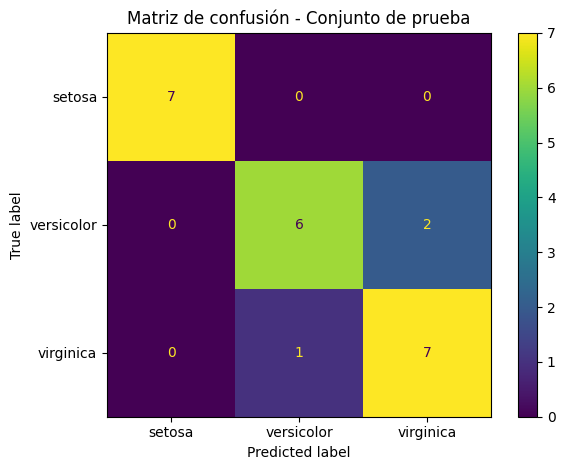

In [65]:
# ============================================================
# 40. MATRIZ DE CONFUSIÓN
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

matriz_confusion = confusion_matrix(
    etiquetas_reales,
    etiquetas_predichas
)

display_matriz = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=iris.target_names
)

display_matriz.plot()
plt.title("Matriz de confusión - Conjunto de prueba")
plt.tight_layout()
plt.show()

## 41. Reporte por clase

In [66]:
# ============================================================
# 41. REPORTE DE CLASIFICACIÓN
# ============================================================

from sklearn.metrics import classification_report

print(
    classification_report(
        etiquetas_reales,
        etiquetas_predichas,
        target_names=iris.target_names,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000         7
  versicolor     0.8571    0.7500    0.8000         8
   virginica     0.7778    0.8750    0.8235         8

    accuracy                         0.8696        23
   macro avg     0.8783    0.8750    0.8745        23
weighted avg     0.8730    0.8696    0.8691        23



## 42. Guardar modelo y métricas

In [67]:
# ============================================================
# 42. GUARDADO DE RESULTADOS
# ============================================================

from pathlib import Path

directorio_resultados = Path("outputs")
directorio_resultados.mkdir(exist_ok=True)

# Guardar historial de entrenamiento
df_historial.to_csv(
    directorio_resultados / "metricas_entrenamiento.csv",
    index=False
)

# Guardar el modelo y su configuración
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_size": 4,
        "hidden_size_1": 16,
        "hidden_size_2": 8,
        "num_classes": 3,
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCHS,
        "seed": SEED,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy
    },
    directorio_resultados / "modelo_iris.pth"
)

print("Archivos guardados correctamente:")
print("- outputs/metricas_entrenamiento.csv")
print("- outputs/modelo_iris.pth")

Archivos guardados correctamente:
- outputs/metricas_entrenamiento.csv
- outputs/modelo_iris.pth


## Interpretación final

Durante las 50 épocas se pudo observar que el modelo fue aprendiendo de manera progresiva. La pérdida de entrenamiento y validación fue disminuyendo, mientras que el accuracy fue aumentando.

Al finalizar el entrenamiento, el modelo obtuvo un accuracy de 92,38 % en los datos de entrenamiento y de 90,91 % en los datos de validación. Como ambos resultados son cercanos y la pérdida de validación continuó disminuyendo, no se observaron señales importantes de overfitting.

Luego el modelo fue evaluado sobre el conjunto de prueba, formado por datos que no se utilizaron durante el entrenamiento ni la validación. En este conjunto obtuvo una pérdida de 0,3059 y un accuracy de 86,96 %, clasificando correctamente 20 de las 23 observaciones.

Al analizar la matriz de confusión, se observa que todas las flores de la especie setosa fueron clasificadas correctamente. Los errores se produjeron entre las especies versicolor y virginica, que fueron confundidas en algunos casos.

En general, considero que el modelo logró aprender a diferenciar las tres especies del dataset Iris y obtuvo un buen desempeño sobre datos no vistos.

In [68]:
# Compresion de archivos generados durante el experimento

!zip -r outputs.zip outputs

  adding: outputs/ (stored 0%)
  adding: outputs/modelo_iris.pth (deflated 48%)
  adding: outputs/metricas_entrenamiento.csv (deflated 66%)
